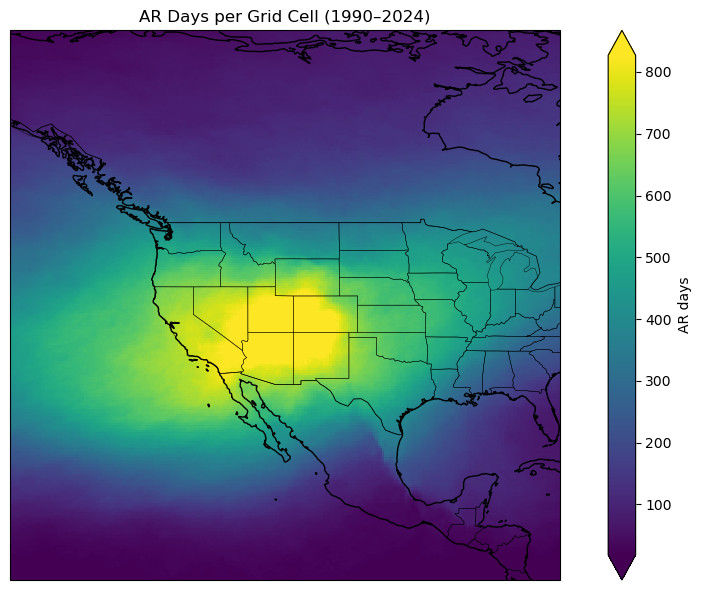

In [5]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


path_to_data = '/cw3e/mead/projects/cwp162/data/'
path_to_out  = 'out/'       # output files (numerical results, intermediate datafiles) -- read & write
path_to_figs = 'figs/'      # figures

# Load ARIDs from CSV
arid_df = pd.read_csv(
    f"{path_to_out}unique_ARIDs.csv",
    dtype={"ARID": "int64"}
)
ARID_all = arid_df["ARID"].values

start_date = '1990-01-01'
end_date = '2024-12-31'

fname = path_to_data + 'downloads/globalARcatalog_ERA5_1940-2024_v4.0.nc'
ds = xr.open_dataset(fname, chunks="auto")[["kidmap"]]
ds = ds.isel(lev=0, ens=0)
ds = ds.assign_coords({"lon": (((ds.lon + 180) % 360) - 180)}) # Convert DataArray longitude coordinates from 0-359 to -180-179
latmin, latmax, lonmin, lonmax = 10., 70., -140., -80.
ds = ds.sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax))
ds = ds.sel(time=slice(start_date, end_date))
ds = ds.chunk({"time": 1000})

mask = ds.kidmap.isin(ARID_all)
daily = mask.resample(time="1D").any()
ar_day_count = daily.sum("time")

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=proj)

# Set map extent (lon_min, lon_max, lat_min, lat_max)
ax.set_extent([lonmin, lonmax, latmin, latmax], crs=proj)

# Plot
ar_day_count.plot(
    ax=ax,
    transform=proj,
    cmap="viridis",
    cbar_kwargs={"label": "AR days"},
    robust=True
)

# Add geographic features
ax.coastlines(resolution="50m", linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)

ax.set_title("AR Days per Grid Cell (1990–2024)")

plt.tight_layout()
plt.show()
